# Ionospheric Conductance Data Validation

This notebook reads and visualizes ionospheric conductance data from IPE model output file.

In [5]:
# Import all required libraries
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

# Configuration parameters
CONFIG = {
    'titleModel': 'IPE',
    'path': '/glade/derecho/scratch/naomi/save/sword/test/IPE/test/run/',
    'component': 'Hall',  # 'Pedersen' or 'Hall'
    'filename': 'fort.4026',
    'nlon': 81, # kmlonp1 !=kmlon+1
    'nlat': 97, 
    'colormap': 'jet',
    'time_label': '00',
    'lat_index': 77,  # Latitude index for cross-section plots (45 degrees)
    'plot_params': {
        'zmin': -1.0,
        'zmax': 2.25,
        'del_z': 0.05
    }
}

In [6]:
def read_conductance_data(file_path, nlon, nlat, num_timesteps=2):
    """
    Read ionospheric conductance data from file for multiple time steps.
    
    Parameters:
    -----------
    file_path : str
        Path to the data file
    nlon : int
        Number of longitude points
    nlat : int
        Number of latitude points
    num_timesteps : int
        Number of time steps to read (default: 2)
        
    Returns:
    --------
    dict
        Dictionary containing data for each time step:
        {
            'longitude': longitude_array,
            'latitude': latitude_array,
            'timesteps': {
                0: {'hall_cond': array, 'pedersen_cond': array},
                1: {'hall_cond': array, 'pedersen_cond': array},
                ...
            }
        }
    """
    n_max_per_timestep = nlon * nlat
    total_points_to_read = n_max_per_timestep * num_timesteps
    
    # Initialize arrays
    longitude = np.zeros(nlon)
    latitude = np.zeros(nlat)
    
    # Initialize timestep data storage
    timesteps_data = {}
    for t in range(num_timesteps):
        timesteps_data[t] = {
            'hall_cond': np.zeros((nlat, nlon)),
            'pedersen_cond': np.zeros((nlat, nlon))
        }
    
    try:
        with open(file_path, 'r') as f:
            for line_count, line in enumerate(f):
                if line_count >= total_points_to_read:
                    break
                
                # Determine which time step and grid indices
                timestep = line_count // n_max_per_timestep
                point_in_timestep = line_count % n_max_per_timestep
                i = point_in_timestep % nlon
                j = point_in_timestep // nlon
                
                # Parse line data
                columns = line.strip().split()
                if len(columns) < 4:
                    continue
                    
                mlon_deg = float(columns[0])  # magnetic longitude [deg]
                mlat_deg = float(columns[1])  # magnetic latitude [deg]
                hall = float(columns[2])      # hall conductance [mho]
                pedersen = float(columns[3])  # pedersen conductance [mho]
                
                # Store data (using log10 for visualization)
                if timestep < num_timesteps:
                    timesteps_data[timestep]['hall_cond'][j, i] = np.log10(hall)
                    timesteps_data[timestep]['pedersen_cond'][j, i] = np.log10(pedersen)
                
                # Store coordinate arrays only once (from first timestep)
                if timestep == 0:
                    latitude[j] = mlat_deg
                    if j == 0:  # Store longitude only once
                        longitude[i] = mlon_deg
                    
    except FileNotFoundError:
        print(f"Error: File {file_path} not found")
        return None
    except Exception as e:
        print(f"Error reading file: {e}")
        return None
    
    print(f"Successfully read {line_count + 1} data points for {num_timesteps} time steps")
    
    return {
        'longitude': longitude,
        'latitude': latitude,
        'timesteps': timesteps_data
    }

In [7]:
def plot_conductance(longitude, latitude, conductance_data, component, 
                     title_model, time_label, plot_params, save_path=None):
    """
    Create a contour plot of ionospheric conductance.
    
    Parameters:
    -----------
    longitude : array
        Longitude grid
    latitude : array
        Latitude grid
    conductance_data : 2D array
        Conductance data (log10 values)
    component : str
        'Hall' or 'Pedersen'
    title_model : str
        Model name for title
    time_label : str
        Time label for title
    plot_params : dict
        Plotting parameters (zmin, zmax, del_z)
    save_path : str, optional
        Path to save the figure
        
    Returns:
    --------
    tuple
        (figure, axes) objects
    """
    # Create levels for contour plot
    levels = np.arange(plot_params['zmin'], 
                      plot_params['zmax'] + plot_params['del_z'], 
                      plot_params['del_z'])
    
    # Create figure with proper size
    fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
    
    # Create contour plot
    contour = ax.contourf(longitude, latitude, conductance_data, 
                         levels=levels, cmap='jet', antialiased=False)
    
    # Set labels and title
    ax.set_title(f'{title_model} {component} Ionospheric Conductance [log10 mho] {time_label}UT')
    ax.set_xlabel('Magnetic Longitude [Degrees]')
    ax.set_ylabel('Magnetic Latitude [Degrees]')
    
    # Add colorbar
    cbar = fig.colorbar(contour, ax=ax)
    cbar.set_label('log10(Conductance) [mho]')
    
    # Save figure if path provided
    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to: {save_path}")
    
    plt.show()
    return fig, ax

Reading data from: /glade/derecho/scratch/naomi/save/sword/test/IPE/test/run/fort.4026
Successfully read 7857 data points for 2 time steps
Time step 0 - Hall conductance range: -0.915 to 2.488
Time step 0 - Pedersen conductance range: -1.773 to 2.237
Time step 1 - Hall conductance range: 0.000 to 0.000
Time step 1 - Pedersen conductance range: 0.000 to 0.000
Figure saved to: /glade/derecho/scratch/naomi/save/sword/test/IPE/test/run/fig/Hallconductance_IPE_00UT_timestep0.png


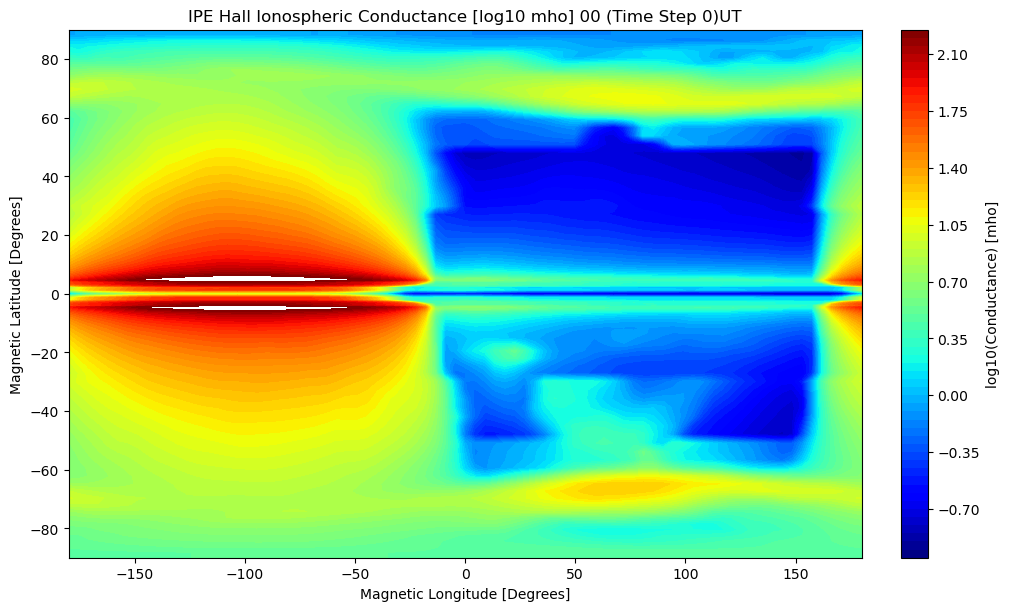

In [8]:
# Read and process data for multiple time steps
file_path = Path(CONFIG['path']) / CONFIG['filename']
print(f"Reading data from: {file_path}")

# Read the data for 2 time steps
num_timesteps = 2
data = read_conductance_data(str(file_path), CONFIG['nlon'], CONFIG['nlat'], num_timesteps)

if data is not None:
    longitude = data['longitude']
    latitude = data['latitude']
    
    # Extract data for each time step
    timestep_0 = data['timesteps'][0]
    timestep_1 = data['timesteps'][1]
    
    print(f"Time step 0 - Hall conductance range: {timestep_0['hall_cond'].min():.3f} to {timestep_0['hall_cond'].max():.3f}")
    print(f"Time step 0 - Pedersen conductance range: {timestep_0['pedersen_cond'].min():.3f} to {timestep_0['pedersen_cond'].max():.3f}")
    print(f"Time step 1 - Hall conductance range: {timestep_1['hall_cond'].min():.3f} to {timestep_1['hall_cond'].max():.3f}")
    print(f"Time step 1 - Pedersen conductance range: {timestep_1['pedersen_cond'].min():.3f} to {timestep_1['pedersen_cond'].max():.3f}")
    
    # Select data for the first time step (for backward compatibility)
    if CONFIG['component'] == 'Hall':
        data_to_plot = timestep_0['hall_cond']
    else:
        data_to_plot = timestep_0['pedersen_cond']
    
    # Create output path for figures
    fig_path = Path(CONFIG['path']) / 'fig' / f"{CONFIG['component']}conductance_{CONFIG['titleModel']}_{CONFIG['time_label']}UT_timestep0.png"
    
    # Plot the data for the first time step
    fig, ax = plot_conductance(
        longitude, latitude, data_to_plot, 
        CONFIG['component'], CONFIG['titleModel'], 
        CONFIG['time_label'] + ' (Time Step 0)', CONFIG['plot_params'],
        save_path=str(fig_path)
    )
else:
    print("Failed to read data. Please check file path and format.")

Figure saved to: /glade/derecho/scratch/naomi/save/sword/test/IPE/test/run/fig/Hallconductance_IPE_00UT_timestep1.png


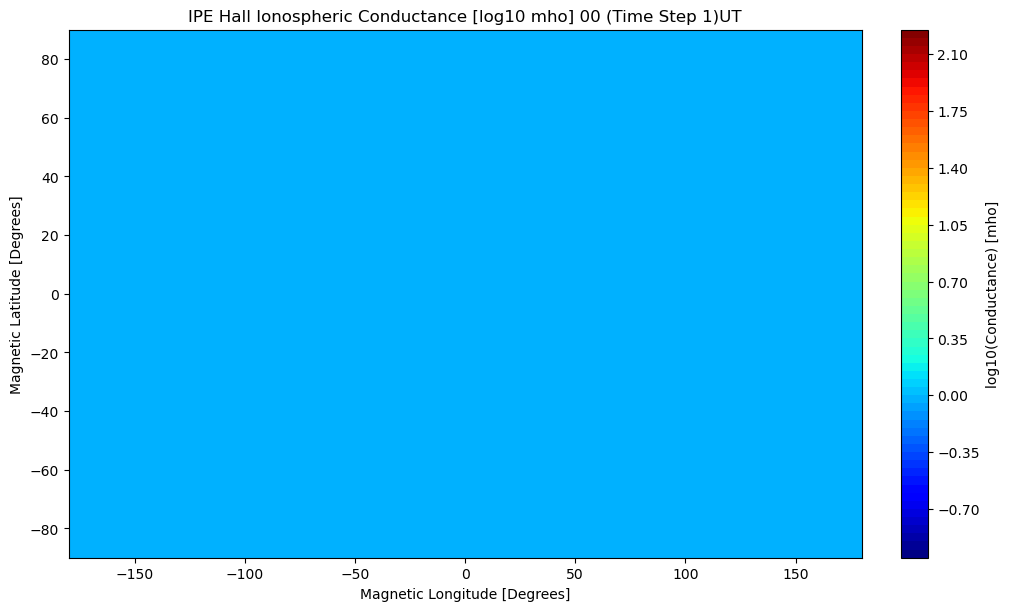

In [9]:
# Plot the second time step
if data is not None:
    # Select data for the second time step
    if CONFIG['component'] == 'Hall':
        data_to_plot_t1 = timestep_1['hall_cond']
    else:
        data_to_plot_t1 = timestep_1['pedersen_cond']
    
    # Create output path for figures
    fig_path_t1 = Path(CONFIG['path']) / 'fig' / f"{CONFIG['component']}conductance_{CONFIG['titleModel']}_{CONFIG['time_label']}UT_timestep1.png"
    
    # Plot the data for the second time step
    fig_t1, ax_t1 = plot_conductance(
        longitude, latitude, data_to_plot_t1, 
        CONFIG['component'], CONFIG['titleModel'], 
        CONFIG['time_label'] + ' (Time Step 1)', CONFIG['plot_params'],
        save_path=str(fig_path_t1)
    )

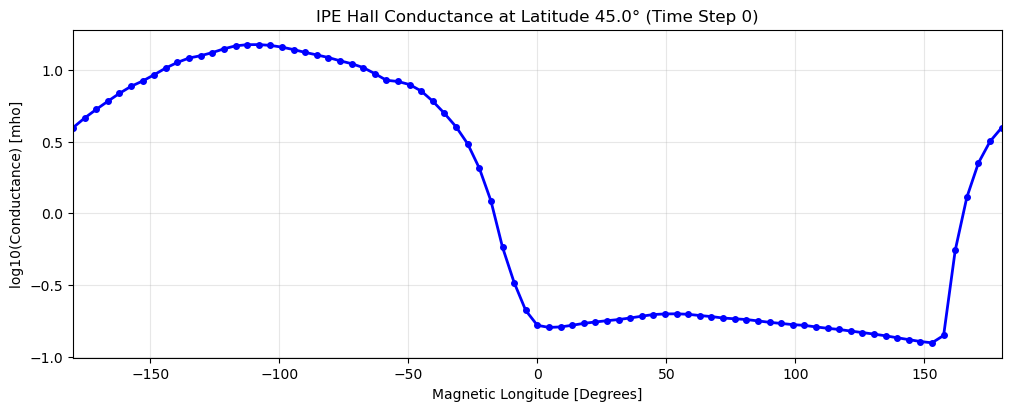

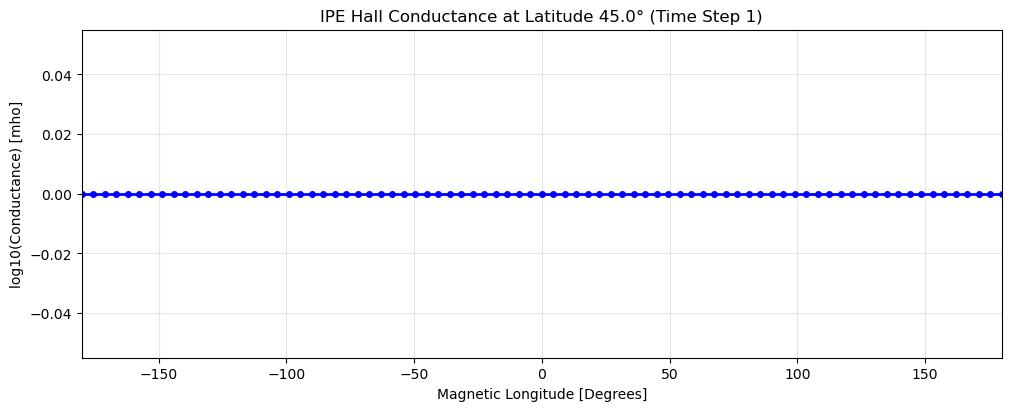

In [10]:
def plot_latitude_cross_section(longitude, latitude, conductance_data, 
                               lat_index, component, title_model, timestep_label=""):
    """
    Plot conductance variation along longitude at a specific latitude.
    
    Parameters:
    -----------
    longitude : array
        Longitude grid
    latitude : array
        Latitude grid
    conductance_data : 2D array
        Conductance data
    lat_index : int
        Latitude index to plot
    component : str
        'Hall' or 'Pedersen'
    title_model : str
        Model name
    timestep_label : str
        Additional label for time step
    """
    # Extract 1D cross-section
    cross_section = conductance_data[lat_index, :]
    
    # Create plot
    fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
    ax.plot(longitude, cross_section, 'b-', linewidth=2, marker='o', markersize=4)
    
    # Labels and title
    ax.set_xlabel('Magnetic Longitude [Degrees]')
    ax.set_ylabel('log10(Conductance) [mho]')
    title = f'{title_model} {component} Conductance at Latitude {latitude[lat_index]:.1f}°'
    if timestep_label:
        title += f' {timestep_label}'
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    
    # Set x-axis limits
    ax.set_xlim(-180, 180)
    
    plt.show()
    return fig, ax

# Cross-section plots for both time steps
if data is not None:
    # Time step 0
    fig_cross_t0, ax_cross_t0 = plot_latitude_cross_section(
        longitude, latitude, data_to_plot, CONFIG['lat_index'], 
        CONFIG['component'], CONFIG['titleModel'], "(Time Step 0)"
    )
    
    # Time step 1
    fig_cross_t1, ax_cross_t1 = plot_latitude_cross_section(
        longitude, latitude, data_to_plot_t1, CONFIG['lat_index'], 
        CONFIG['component'], CONFIG['titleModel'], "(Time Step 1)"
    )

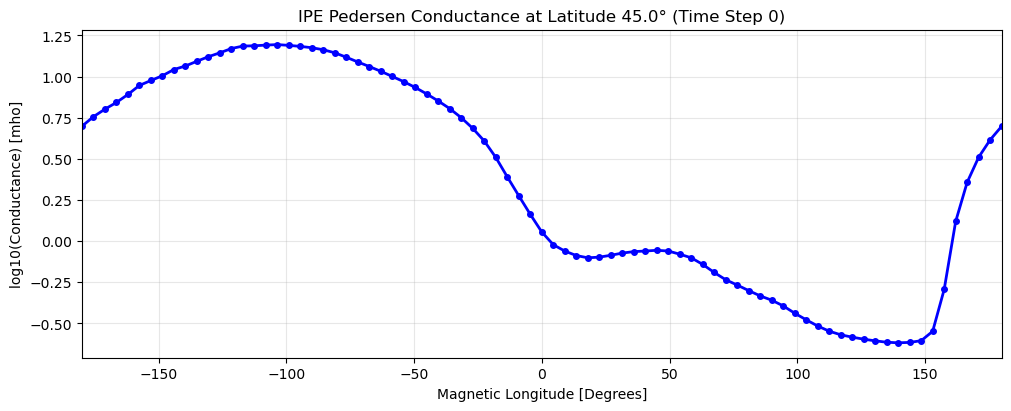

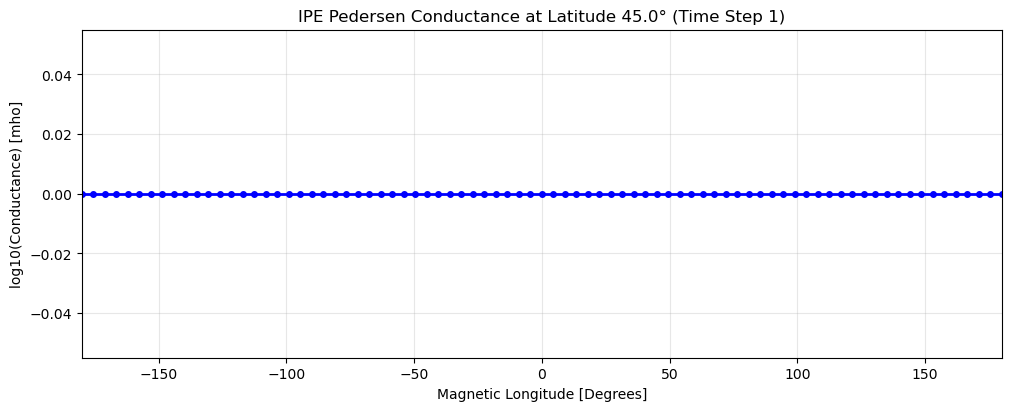

In [11]:
# Pedersen conductance cross-section plots for both time steps
if data is not None:
    # Time step 0
    fig_pedersen_t0, ax_pedersen_t0 = plot_latitude_cross_section(
        longitude, latitude, timestep_0['pedersen_cond'], CONFIG['lat_index'], 
        'Pedersen', CONFIG['titleModel'], "(Time Step 0)"
    )
    
    # Time step 1
    fig_pedersen_t1, ax_pedersen_t1 = plot_latitude_cross_section(
        longitude, latitude, timestep_1['pedersen_cond'], CONFIG['lat_index'], 
        'Pedersen', CONFIG['titleModel'], "(Time Step 1)"
    )

Comparison plot for time step 0 saved to: /glade/derecho/scratch/naomi/save/sword/test/IPE/test/run/fig/Hall_vs_Pedersen_conductance_comparison_IPE_00UT_timestep0.png


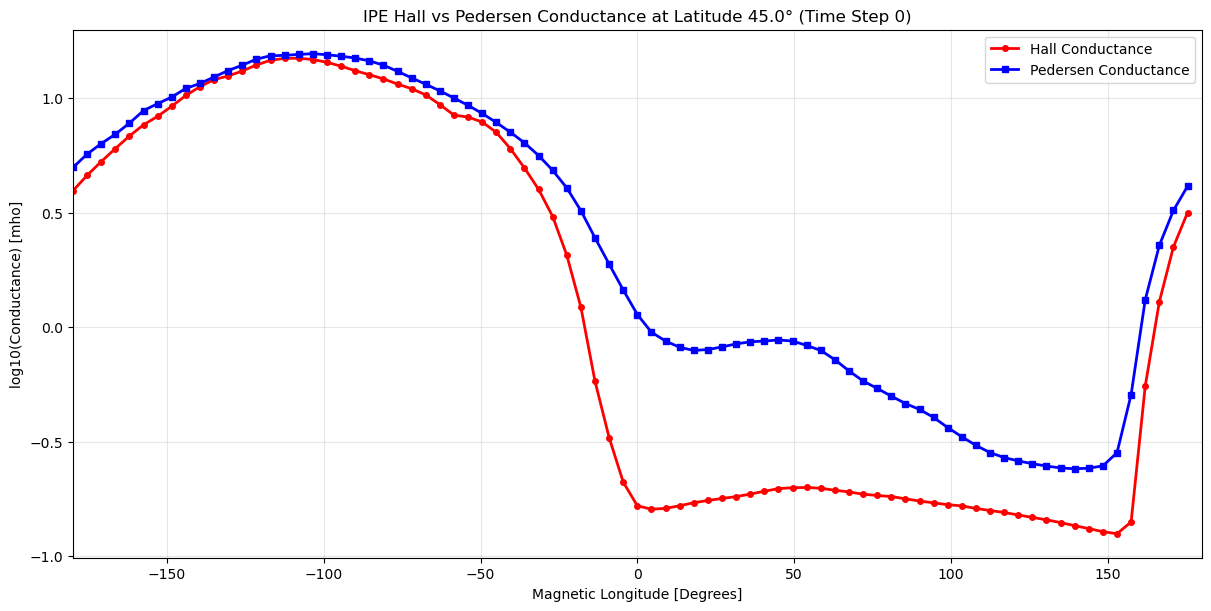

Comparison plot for time step 1 saved to: /glade/derecho/scratch/naomi/save/sword/test/IPE/test/run/fig/Hall_vs_Pedersen_conductance_comparison_IPE_00UT_timestep1.png


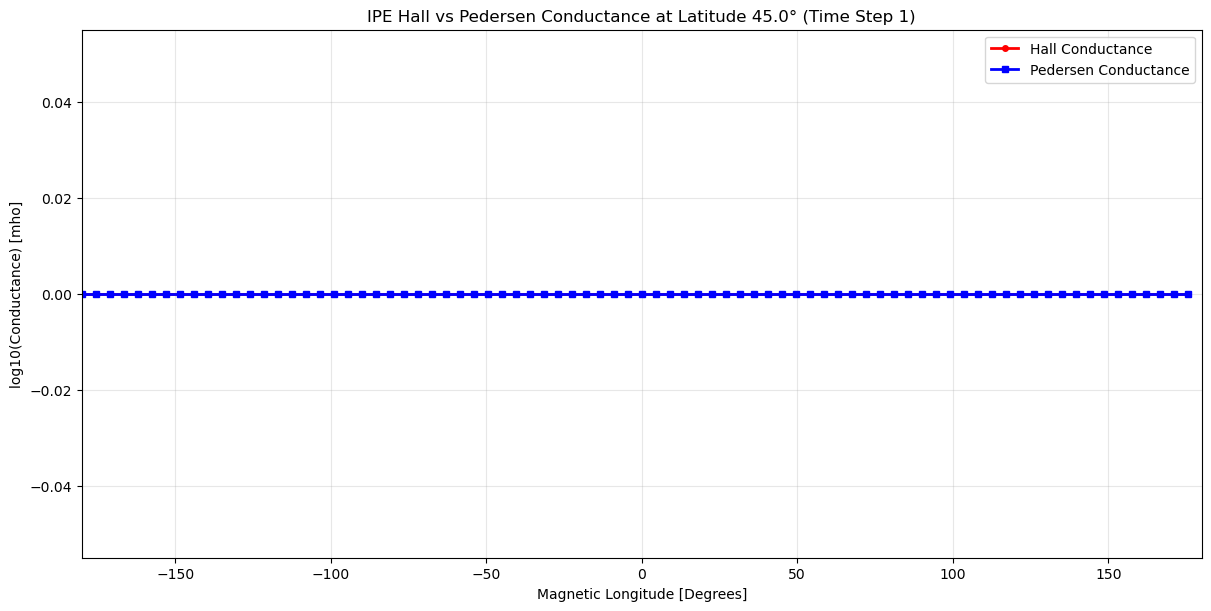

In [8]:
# Comparison plots: Hall vs Pedersen conductance for both time steps
if data is not None:
    for t in range(2):
        timestep_data = data['timesteps'][t]
        
        # Extract cross-sections for both components
        hall_cross_section = timestep_data['hall_cond'][CONFIG['lat_index'], :]
        pedersen_cross_section = timestep_data['pedersen_cond'][CONFIG['lat_index'], :]
        
        # Create comparison plot
        fig_compare, ax_compare = plt.subplots(figsize=(12, 6), constrained_layout=True)
        
        # Plot both lines
        ax_compare.plot(longitude, hall_cross_section, 'r-', linewidth=2, 
                       marker='o', markersize=4, label='Hall Conductance')
        ax_compare.plot(longitude, pedersen_cross_section, 'b-', linewidth=2, 
                       marker='s', markersize=4, label='Pedersen Conductance')
        
        # Labels and title
        ax_compare.set_xlabel('Magnetic Longitude [Degrees]')
        ax_compare.set_ylabel('log10(Conductance) [mho]')
        ax_compare.set_title(f'{CONFIG["titleModel"]} Hall vs Pedersen Conductance at Latitude {latitude[CONFIG["lat_index"]]:.1f}° (Time Step {t})')
        ax_compare.grid(True, alpha=0.3)
        ax_compare.legend()
        
        # Set x-axis limits
        ax_compare.set_xlim(-180, 180)
        
        # Save the figure
        comparison_fig_path = Path(CONFIG['path']) / 'fig' / f"Hall_vs_Pedersen_conductance_comparison_{CONFIG['titleModel']}_{CONFIG['time_label']}UT_timestep{t}.png"
        Path(comparison_fig_path).parent.mkdir(parents=True, exist_ok=True)
        fig_compare.savefig(comparison_fig_path, dpi=300, bbox_inches='tight')
        print(f"Comparison plot for time step {t} saved to: {comparison_fig_path}")
        
        plt.show()